# Read in the Data To Python

In [6]:
import pandas as pd

meta_stock = pd.read_csv('Meta_stock_log.csv')
print(meta_stock.dtypes)
meta_stock.tail()

Date                        object
Open                       float64
Close                      float64
Up/Down                     object
Change in stock price      float64
Actual up/down tomorrow      int64
dtype: object


,Date,Open,Close,Up/Down,Change in stock price,Actual up/down tomorrow
1506,21/04/2022,201.600006,188.070007,Down,-13.529999,0
1507,22/04/2022,190.369995,184.110001,Down,-6.259994,1
1508,25/04/2022,182.729996,186.990005,Up,4.260009,0
1509,26/04/2022,186.630005,180.949997,Down,-5.680008,1
1510,27/04/2022,174.429993,174.949997,Up,0.520004,0


# Plan the Model

In [7]:
from sklearn.model_selection import train_test_split

train,test = train_test_split(meta_stock,
                             random_state = 15)

In [8]:
dependent = train['Actual up/down tomorrow']
independent = train['Change in stock price']

In [9]:
import statsmodels.api as sm

independent = sm.add_constant(independent)

# Model Building

In [12]:
model = sm.Logit(
    dependent,
    independent
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.689736
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                              Logit Regression Results                             
===================================================================================
Dep. Variable:     Actual up/down tomorrow   No. Observations:                 1133
Model:                               Logit   Df Residuals:                     1131
Method:                                MLE   Df Model:                            1
Date:                     Wed, 17 Sep 2025   Pseudo R-squ.:                0.004451
Time:                             18:00:40   Log-Likelihood:                -781.47
converged:                            True   LL-Null:                       -784.96
Covariance Type:                 nonrobust   LLR p-value:                  0.008208
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.0508      0.060      0.852      0.394      -0.066       0.168
Change in stock price    -0.0453      0.017     -2.619      0.009      -0.079      -0.011
=========================================================================================
"""

# Measuring Success

In [15]:
new_independent = sm.add_constant(test[['Change in stock price']])

predicted = (model.predict(new_independent) >= 0.5)

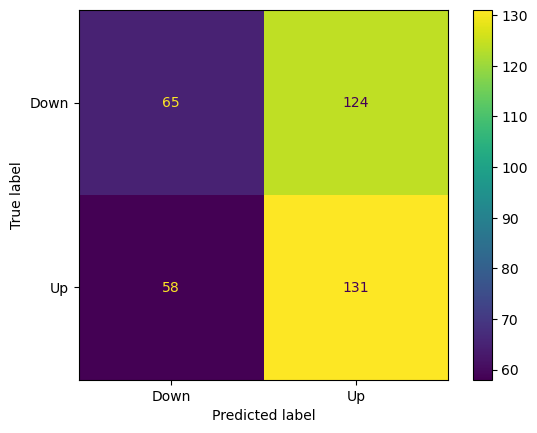

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

new_dependent = test['Actual up/down tomorrow']

cm = confusion_matrix(
        new_dependent,
        predicted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Down','Up'])
disp.plot();



In [ ]:
model.

In [13]:
test

,Date,Open,Close,Up/Down,Change in stock price,Actual up/down tomorrow
683,15/01/2019,146.009995,148.949997,Up,2.940002,0
1027,28/05/2020,224.300003,225.460007,Up,1.160004,0
103,23/09/2016,127.559998,127.959999,Up,0.400001,0
350,18/09/2017,171.990005,170.009995,Down,-1.980010,1
497,19/04/2018,166.199997,168.100006,Up,1.900009,0
...,...,...,...,...,...,...
1451,01/02/2022,314.559998,319.000000,Up,4.440002,0
1184,11/01/2021,260.480011,256.839996,Down,-3.640015,0
644,15/11/2018,142.330002,143.850006,Up,1.520004,0
554,11/07/2018,202.220001,202.539993,Up,0.319992,1
